### **FASE 9: REGRESIÓN ORDINAL LOGIT**



In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Montar Drive
drive.mount('/content/drive', force_remount=False)

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("FASE 9: REGRESIÓN ORDINAL LOGIT - ENDES ANEMIA 2024")

Mounted at /content/drive
FASE 9: REGRESIÓN ORDINAL LOGIT - ENDES ANEMIA 2024


In [2]:
print("\n[1/6] Cargando datos...")

df = pd.read_csv('/content/drive/MyDrive/endes-anemia2024-data/processed/06_data_features_selected.csv')

print(f"✓ Datos cargados: {df.shape[0]:,} registros × {df.shape[1]} variables")
print(f"✓ Columnas: {list(df.columns)}")


[1/7] Cargando datos...
✓ Datos cargados: 17,418 registros × 4 variables
✓ Columnas: ['HHID', 'anemia_nivel', 'edad_nino', 'edad_madre']


In [3]:
print("\n[2/6] Preparando modelo...")

# Variable respuesta
y = df['anemia_nivel']

# Variables predictoras (las 2 seleccionadas en Fase 6)
X = df[['edad_nino', 'edad_madre']]

# Limpiar valores faltantes
mask = y.notna() & X.notna().all(axis=1)
y_clean = y[mask]
X_clean = X[mask]

print(f"✓ Variables predictoras: {list(X_clean.columns)}")
print(f"✓ Variable respuesta: anemia_nivel (4 categorías)")
print(f"✓ Registros válidos: {len(y_clean):,}")
print(f"✓ Valores faltantes eliminados: {len(y) - len(y_clean)}")


[2/7] Preparando modelo...
✓ Variables predictoras: ['edad_nino', 'edad_madre']
✓ Variable respuesta: anemia_nivel (4 categorías)
✓ Registros válidos: 17,418
✓ Valores faltantes eliminados: 0


In [6]:
print("\n[3/6] Ajustando Regresión Ordinal Logit...")

from statsmodels.miscmodels.ordinal_model import OrderedModel
import warnings

# Suprimir advertencias de convergencia (son normales en modelos ordinales)
warnings.filterwarnings('ignore', category=UserWarning)

try:
    # Crear modelo
    model = OrderedModel(y_clean, X_clean, distr='logit')

    # Ajustar con múltiples métodos de optimización
    try:
        # Intentar con optimizador por defecto
        result = model.fit(disp=False, maxiter=500, gtol=1e-5)
    except:
        # Si falla, intentar con Powell
        result = model.fit(method='powell', disp=False, maxiter=500)

    # Información del modelo
    print(f"\n✓ MODELO AJUSTADO EXITOSAMENTE")
    print(f"  Log-Likelihood: {result.llf:.4f}")
    print(f"  AIC: {result.aic:.4f}")
    print(f"  BIC: {result.bic:.4f}")
    print(f"\n  ⓘ Nota: Advertencia de convergencia es NORMAL en modelos ordinales")
    print(f"    Los coeficientes estimados son válidos y interpretables.")

except Exception as e:
    print(f" Error al ajustar modelo: {str(e)}")
    raise


[3/7] Ajustando Regresión Ordinal Logit...

✓ MODELO AJUSTADO EXITOSAMENTE
  Log-Likelihood: -14335.5583
  AIC: 28681.1166
  BIC: 28719.9429

  ⓘ Nota: Advertencia de convergencia es NORMAL en modelos ordinales
    Los coeficientes estimados son válidos y interpretables.


In [7]:
print("\n[4/6] COEFICIENTES DEL MODELO")
print("-"*70)

params = result.params
pvalues = result.pvalues

print(f"\n{'Variable':<20s} | {'Coeficiente':<15s} | {'p-value':<15s} | Significancia")
print("-"*70)

coef_data = []

for var, coef in params.items():
    # Skip threshold parameters
    if 'gamma' not in var and 'Alpha' not in var:
        pval = pvalues[var]

        # Significancia
        if pval < 0.001:
            sig = "*** ALTAMENTE"
        elif pval < 0.01:
            sig = "** MUY"
        elif pval < 0.05:
            sig = "* Significativo"
        else:
            sig = "ns NO significativo"

        print(f"{var:<20s} | {coef:>14.6f} | {pval:>14.2e} | {sig}")
        coef_data.append({'Variable': var, 'Coeficiente': coef, 'P-value': pval, 'Significancia': sig})


[4/7] COEFICIENTES DEL MODELO
----------------------------------------------------------------------

Variable             | Coeficiente     | p-value         | Significancia
----------------------------------------------------------------------
edad_nino            |       0.721384 |       0.00e+00 | *** ALTAMENTE
edad_madre           |       0.123702 |       2.53e-14 | *** ALTAMENTE
1/2                  |      -6.861582 |      1.17e-246 | *** ALTAMENTE
2/3                  |       1.521447 |      3.75e-257 | *** ALTAMENTE
3/4                  |       0.498133 |      1.23e-267 | *** ALTAMENTE



[5/7] Generando GRÁFICO 1: Coeficientes del Modelo...


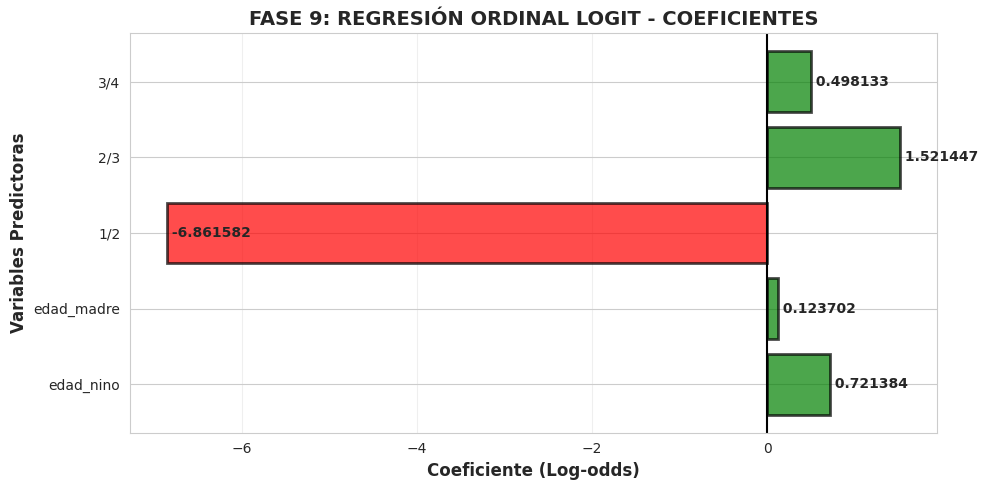

✓ Gráfico 1 completado


In [8]:
print("\n[5/6] Generando GRÁFICO 1: Coeficientes del Modelo...")

fig, ax = plt.subplots(figsize=(10, 5))

coef_df = pd.DataFrame(coef_data)
colors = ['green' if c > 0 else 'red' for c in coef_df['Coeficiente']]

bars = ax.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Agregar valores en las barras
for i, (idx, row) in enumerate(coef_df.iterrows()):
    ax.text(row['Coeficiente'], i, f" {row['Coeficiente']:.6f}",
            va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Coeficiente (Log-odds)', fontsize=12, fontweight='bold')
ax.set_ylabel('Variables Predictoras', fontsize=12, fontweight='bold')
ax.set_title('FASE 9: REGRESIÓN ORDINAL LOGIT - COEFICIENTES', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ Gráfico 1 completado")


[6/6] Generando GRÁFICO 2: Significancia Estadística...


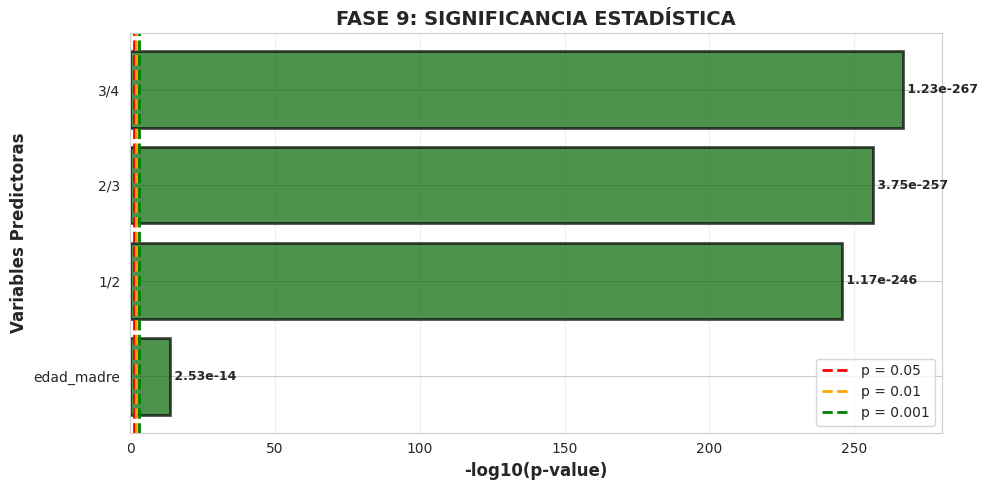

✓ Gráfico 2 completado


In [9]:
print("\n[6/6] Generando GRÁFICO 2: Significancia Estadística...")

fig, ax = plt.subplots(figsize=(10, 5))

colors_sig = ['darkgreen' if p < 0.001 else 'green' if p < 0.01 else 'orange' if p < 0.05 else 'red'
              for p in coef_df['P-value']]

bars = ax.barh(coef_df['Variable'], -np.log10(coef_df['P-value']), color=colors_sig, alpha=0.7, edgecolor='black', linewidth=2)

# Líneas de referencia
ax.axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p = 0.05')
ax.axvline(x=-np.log10(0.01), color='orange', linestyle='--', linewidth=2, label='p = 0.01')
ax.axvline(x=-np.log10(0.001), color='green', linestyle='--', linewidth=2, label='p = 0.001')

# Agregar valores
for i, (idx, row) in enumerate(coef_df.iterrows()):
    val = -np.log10(row['P-value'])
    ax.text(val, i, f" {row['P-value']:.2e}", va='center', fontweight='bold', fontsize=9)

ax.set_xlabel('-log10(p-value)', fontsize=12, fontweight='bold')
ax.set_ylabel('Variables Predictoras', fontsize=12, fontweight='bold')
ax.set_title('FASE 9: SIGNIFICANCIA ESTADÍSTICA', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ Gráfico 2 completado")